In [64]:
import geopandas as gpd

# python -m ipykernel install --user --name geo-sylv --display-name "Python (geo-sylv)"

project = gpd.read_file("data/projects/project_001/geometry.geojson")

# projete en lambert
project = project.to_crs(epsg=2154)

# area dans l'unité du crs ici m2
area_ha = project.geometry.area / 10000
print(area_ha)

0    12584.534459
dtype: float64


<Axes: >

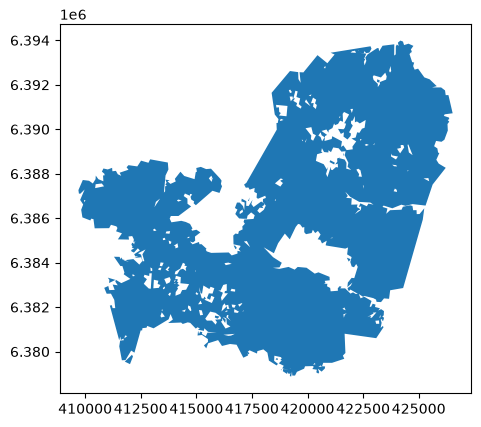

In [65]:
project.plot()

In [66]:
# project.geometry.iloc[0] un seul item dans geometry 
geom = project.geometry.iloc[0]

print(type(geom))
print(len(geom.geoms))

<class 'shapely.geometry.multipolygon.MultiPolygon'>
14


In [67]:
# chaque polygon de geoms a sa propre area 
for i, poly in enumerate(geom.geoms):
    print(i, poly.area / 10_000, "ha")

0 6.718663217618495 ha
1 0.5401013308575542 ha
2 1.738416145046769 ha
3 3.286571338179367 ha
4 1.0523096987092508 ha
5 12565.991068054844 ha
6 0.3276062091027232 ha
7 0.09547986900780481 ha
8 1.2332381523979108 ha
9 1.9801274209346638 ha
10 0.04204808057373602 ha
11 0.2547249141649994 ha
12 1.2334008163297432 ha
13 0.040704122031028814 ha


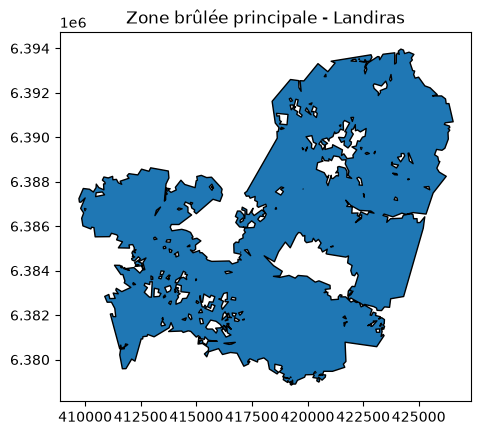

In [68]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# Polygon represente un figure qui est fermé par une ligne continue

# on récupère le polygone principal (celui avec l'aire max)
main_poly = geom.geoms[5]

gpd.GeoSeries([main_poly], crs="EPSG:2154").plot(edgecolor="black")
plt.title("Zone brûlée principale - Landiras")
plt.show()

In [69]:
print("Nombre de trous (interiors) :", len(main_poly.interiors))

# surface totale des trous
from shapely.geometry import Polygon

holes_area = sum(Polygon(ring).area for ring in main_poly.interiors) / 10_000
print("Surface totale des trous :", holes_area, "ha")

main_poly_filled = Polygon(main_poly.exterior)

print("Aire remplie (sans trous) :", main_poly_filled.area / 10_000, "ha")
print("Aire originale (avec trous) :", main_poly.area / 10_000, "ha")

Nombre de trous (interiors) : 101
Surface totale des trous : 1103.228969212366 ha
Aire remplie (sans trous) : 13669.220037267218 ha
Aire originale (avec trous) : 12565.991068054844 ha


In [70]:
# on isole le trou principal (le plus grand)
hole_areas = [Polygon(ring).area for ring in main_poly.interiors]
main_hole = Polygon(main_poly.interiors[hole_areas.index(max(hole_areas))])

print("Aire du trou principal :", main_hole.area / 10_000, "ha")

# centroïde en Lambert-93, puis reprojeté en lat/lon pour le lire facilement
centroid_lambert = gpd.GeoSeries([main_hole.centroid], crs="EPSG:2154")
centroid_wgs84 = centroid_lambert.to_crs(epsg=4326)
print("Centroïde (lat/lon) :", centroid_wgs84.iloc[0].y, centroid_wgs84.iloc[0].x)

Aire du trou principal : 572.1136629825886 ha
Centroïde (lat/lon) : 44.500922388052935 -0.5184626640062183


In [71]:
lat, lon = centroid_wgs84.iloc[0].y, centroid_wgs84.iloc[0].x
print(f"Google Maps : https://www.google.com/maps?q={lat},{lon}")
print(f"OpenStreetMap : https://www.openstreetmap.org/?mlat={lat}&mlon={lon}&zoom=15")

Google Maps : https://www.google.com/maps?q=44.500922388052935,-0.5184626640062183
OpenStreetMap : https://www.openstreetmap.org/?mlat=44.500922388052935&mlon=-0.5184626640062183&zoom=15


In [72]:
import os

clean_gdf = gpd.GeoDataFrame(geometry=[main_poly], crs="EPSG:2154").to_crs(epsg=4326)

out_dir = "data/projects/project_001"
os.makedirs(out_dir, exist_ok=True)
clean_gdf.to_file(os.path.join(out_dir, "geometry_clean.geojson"), driver="GeoJSON")

print("Sauvegardé :", os.path.join(out_dir, "geometry_clean.geojson"))
print("Nouvelle surface :", clean_gdf.to_crs(epsg=2154).geometry.area.sum() / 10_000, "ha")

Sauvegardé : data/projects/project_001/geometry_clean.geojson
Nouvelle surface : 12565.991068055311 ha


In [73]:
print("Géométrie valide :", clean_gdf.geometry.is_valid.iloc[0])

bounds = clean_gdf.total_bounds
print("Bounding box (lon_min, lat_min, lon_max, lat_max) :", bounds)

Géométrie valide : True
Bounding box (lon_min, lat_min, lon_max, lat_max) : [-0.65433742 44.45246434 -0.44465849 44.59032436]


In [74]:
from shapely.geometry import box

bbox_geom = box(*bounds)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_geom], crs="EPSG:4326").to_crs(epsg=2154)
bbox_area_ha = bbox_gdf.geometry.area.iloc[0] / 10_000

poly_area_ha = clean_gdf.to_crs(epsg=2154).geometry.area.iloc[0] / 10_000

print("Aire bounding box :", bbox_area_ha, "ha")
print("Aire polygone réel :", poly_area_ha, "ha")
print("Ratio bbox/polygone :", bbox_area_ha / poly_area_ha)

Aire bounding box : 25518.769260151108 ha
Aire polygone réel : 12565.991068055311 ha
Ratio bbox/polygone : 2.0307804710305546


In [75]:
import numpy as np
from shapely.geometry import box as shapely_box

# grille 500m sur la bbox, en Lambert-93
bbox_metric = bbox_gdf.geometry.iloc[0].bounds
xmin, ymin, xmax, ymax = bbox_metric
step = 500

cells = []
x = xmin
while x < xmax:
    y = ymin
    while y < ymax:
        cells.append(shapely_box(x, y, x + step, y + step))
        y += step
    x += step

cells_gdf = gpd.GeoDataFrame(geometry=cells, crs="EPSG:2154")
poly_metric = clean_gdf.to_crs(epsg=2154)

intersecting = cells_gdf[cells_gdf.intersects(poly_metric.geometry.iloc[0])]

print("Nombre total de cases (bbox) :", len(cells_gdf))
print("Nombre de cases intersectant le polygone :", len(intersecting))
print("Pourcentage utile :", len(intersecting) / len(cells_gdf) * 100, "%")

Nombre total de cases (bbox) : 1155
Nombre de cases intersectant le polygone : 638
Pourcentage utile : 55.23809523809524 %


In [76]:
import requests

resp = requests.get('https://stac.dataspace.copernicus.eu/v1/collections?limit=1000')
data = resp.json()


sentinel_collections = [c["id"] for c in data["collections"] if "sentinel" in c["id"].lower()]
print(sentinel_collections)

print("Nombre de collections dans cette page :", len(data["collections"]))
print("Clés disponibles dans la réponse :", data.keys())
print("Liens :", data.get("links"))

"""
search = catalog.search(
    collections=["SENTINEL-2"],
    bbox=bbox,
    datetime="2022-07-01/2022-08-31",
)


items = list(search.items())
print("Nombre de scènes trouvées :", len(items))
print("Première scène :", items[0].id if items else None)
"""

['sentinel-1-etad', 'sentinel-1-global-mosaics', 'sentinel-1-grd', 'sentinel-1-ocn', 'sentinel-1-ocn-wv', 'sentinel-1-slc', 'sentinel-1-slc-burst', 'sentinel-1-slc-wv', 'sentinel-2-global-mosaics', 'sentinel-2-gri-l1c', 'sentinel-2-gri-l1c-gcp', 'sentinel-2-l1c', 'sentinel-2-l2a', 'sentinel-2-l2a-tlm', 'sentinel-2-night-time-acquisitions', 'sentinel-3-olci-1-efr-nrt', 'sentinel-3-olci-1-efr-ntc', 'sentinel-3-olci-1-err-nrt', 'sentinel-3-olci-1-err-ntc', 'sentinel-3-olci-2-lfr-nrt', 'sentinel-3-olci-2-lfr-ntc', 'sentinel-3-olci-2-lrr-nrt', 'sentinel-3-olci-2-lrr-ntc', 'sentinel-3-olci-2-wfr-nrt', 'sentinel-3-olci-2-wfr-ntc', 'sentinel-3-olci-2-wrr-nrt', 'sentinel-3-olci-2-wrr-ntc', 'sentinel-3-sl-1-rbt-nrt', 'sentinel-3-sl-1-rbt-ntc', 'sentinel-3-sl-2-aod-nrt', 'sentinel-3-sl-2-frp-nrt', 'sentinel-3-sl-2-frp-ntc', 'sentinel-3-sl-2-lst-nrt', 'sentinel-3-sl-2-lst-ntc', 'sentinel-3-sl-2-wst-nrt', 'sentinel-3-sl-2-wst-ntc', 'sentinel-3-sr-1-sra-a-nrt', 'sentinel-3-sr-1-sra-a-ntc', 'sentinel

'\nsearch = catalog.search(\n    collections=["SENTINEL-2"],\n    bbox=bbox,\n    datetime="2022-07-01/2022-08-31",\n)\n\n\nitems = list(search.items())\nprint("Nombre de scènes trouvées :", len(items))\nprint("Première scène :", items[0].id if items else None)\n'

In [77]:
from pystac_client import Client

catalog = Client.open("https://catalogue.dataspace.copernicus.eu/stac")

bbox = list(bounds)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2022-07-01/2022-08-31",
)

items = list(search.items())
print("Nombre de scènes trouvées :", len(items))
print("Première scène :", items[0].id if items else None)




Nombre de scènes trouvées : 50
Première scène : S2A_MSIL2A_20220831T105631_N0510_R094_T30TYQ_20240703T102735


In [78]:
for item in items:
    print(item.id, "-", item.properties.get("eo:cloud_cover"), "% nuages")

S2A_MSIL2A_20220831T105631_N0510_R094_T30TYQ_20240703T102735 - 68.469352 % nuages
S2A_MSIL2A_20220831T105631_N0510_R094_T30TXQ_20240703T102735 - 90.566188 % nuages
S2A_MSIL2A_20220828T104631_N0510_R051_T30TYQ_20240703T110747 - 11.485358 % nuages
S2A_MSIL2A_20220828T104631_N0510_R051_T30TXQ_20240703T110747 - 17.38859 % nuages
S2B_MSIL2A_20220826T105619_N0510_R094_T30TYQ_20240708T050349 - 54.984629 % nuages
S2B_MSIL2A_20220826T105619_N0510_R094_T30TXQ_20240708T050349 - 41.891599 % nuages
S2B_MSIL2A_20220823T104619_N0510_R051_T30TYQ_20240704T163824 - 83.578455 % nuages
S2B_MSIL2A_20220823T104619_N0510_R051_T30TXQ_20240704T163824 - 99.715459 % nuages
S2A_MSIL2A_20220821T105631_N0510_R094_T30TYQ_20240709T010115 - 99.999982 % nuages
S2A_MSIL2A_20220821T105631_N0510_R094_T30TXQ_20240709T010115 - 99.935448 % nuages
S2A_MSIL2A_20220818T104631_N0510_R051_T30TYQ_20240704T051817 - 29.41 % nuages
S2A_MSIL2A_20220818T104631_N0510_R051_T30TXQ_20240704T051817 - 57.48 % nuages
S2B_MSIL2A_20220816T10561

In [79]:
threshold = 20
usable = [item for item in items if item.properties.get("eo:cloud_cover", 100) < threshold]

print(f"Scènes utilisables (<{threshold}% nuages) : {len(usable)} sur {len(items)}")
for item in sorted(usable, key=lambda i: i.datetime):
    print(item.id, "-", item.properties.get("eo:cloud_cover"), "%")

Scènes utilisables (<20% nuages) : 25 sur 50
S2A_MSIL2A_20220702T105631_N0510_R094_T30TYQ_20240701T074946 - 0.0 %
S2A_MSIL2A_20220702T105631_N0510_R094_T30TXQ_20240701T074946 - 0.15 %
S2B_MSIL2A_20220707T105629_N0510_R094_T30TYQ_20240701T024200 - 9.88 %
S2B_MSIL2A_20220707T105629_N0510_R094_T30TXQ_20240701T024200 - 6.55 %
S2A_MSIL2A_20220709T105041_N0510_R051_T30TYQ_20240708T052543 - 0.0 %
S2A_MSIL2A_20220709T105041_N0510_R051_T30TXQ_20240708T052543 - 0.01 %
S2A_MSIL2A_20220712T105631_N0510_R094_T30TYQ_20240723T232251 - 0.0016929999999999998 %
S2A_MSIL2A_20220712T105631_N0510_R094_T30TXQ_20240723T232251 - 0.011861 %
S2B_MSIL2A_20220714T104629_N0510_R051_T30TYQ_20240724T011152 - 16.146366 %
S2B_MSIL2A_20220714T104629_N0510_R051_T30TXQ_20240724T011152 - 11.363798 %
S2B_MSIL2A_20220717T105629_N0510_R094_T30TXQ_20240717T092238 - 0.76 %
S2B_MSIL2A_20220724T104629_N0510_R051_T30TYQ_20240715T230846 - 0.0 %
S2B_MSIL2A_20220724T104629_N0510_R051_T30TXQ_20240715T230846 - 0.01 %
S2A_MSIL2A_202208

In [80]:
pre_fire_id_prefix = "S2A_MSIL2A_20220702"
post_fire_id_prefix = "S2A_MSIL2A_20220801"

pre_fire_items = [item for item in items if item.id.startswith(pre_fire_id_prefix)]
post_fire_items = [item for item in items if item.id.startswith(post_fire_id_prefix)]

from shapely.geometry import shape

for item in pre_fire_items:
    tile_geom = shape(item.geometry)  # geometry native de l'item STAC (déjà en WGS84)
    tile_gdf = gpd.GeoDataFrame(geometry=[tile_geom], crs="EPSG:4326")
    
    # intersection avec ton polygone Landiras
    intersection = tile_gdf.geometry.iloc[0].intersection(clean_gdf.geometry.iloc[0])
    
    # % de la surface du polygone Landiras couvert par cette tuile
    inter_metric = gpd.GeoSeries([intersection], crs="EPSG:4326").to_crs(epsg=2154)
    poly_metric = clean_gdf.to_crs(epsg=2154)
    
    pct_covered = inter_metric.area.iloc[0] / poly_metric.geometry.area.iloc[0] * 100
    
    print(item.id, "-", round(pct_covered, 2), "% du polygone Landiras couvert")

S2A_MSIL2A_20220702T105631_N0510_R094_T30TYQ_20240701T074946 - 18.16 % du polygone Landiras couvert
S2A_MSIL2A_20220702T105631_N0510_R094_T30TXQ_20240701T074946 - 100.0 % du polygone Landiras couvert


In [81]:
for item in post_fire_items:
    tile_geom = shape(item.geometry)
    tile_gdf = gpd.GeoDataFrame(geometry=[tile_geom], crs="EPSG:4326")
    
    intersection = tile_gdf.geometry.iloc[0].intersection(clean_gdf.geometry.iloc[0])
    inter_metric = gpd.GeoSeries([intersection], crs="EPSG:4326").to_crs(epsg=2154)
    poly_metric = clean_gdf.to_crs(epsg=2154)
    
    pct_covered = inter_metric.area.iloc[0] / poly_metric.geometry.area.iloc[0] * 100
    
    print(item.id, "-", round(pct_covered, 2), "% du polygone Landiras couvert")

S2A_MSIL2A_20220801T105631_N0510_R094_T30TYQ_20240716T103744 - 18.16 % du polygone Landiras couvert
S2A_MSIL2A_20220801T105631_N0510_R094_T30TXQ_20240716T103744 - 100.0 % du polygone Landiras couvert


In [82]:
pre_fire_item = pre_fire_items[1]  # celui qui correspond à T30TXQ (100% couverture)

for key, asset in pre_fire_item.assets.items():
    print(key, "-", asset.href)

AOT_10m - s3://eodata/Sentinel-2/MSI/L2A_N0500/2022/07/02/S2A_MSIL2A_20220702T105631_N0510_R094_T30TXQ_20240701T074946.SAFE/GRANULE/L2A_T30TXQ_A036699_20220702T105925/IMG_DATA/R10m/T30TXQ_20220702T105631_AOT_10m.jp2
AOT_20m - s3://eodata/Sentinel-2/MSI/L2A_N0500/2022/07/02/S2A_MSIL2A_20220702T105631_N0510_R094_T30TXQ_20240701T074946.SAFE/GRANULE/L2A_T30TXQ_A036699_20220702T105925/IMG_DATA/R20m/T30TXQ_20220702T105631_AOT_20m.jp2
AOT_60m - s3://eodata/Sentinel-2/MSI/L2A_N0500/2022/07/02/S2A_MSIL2A_20220702T105631_N0510_R094_T30TXQ_20240701T074946.SAFE/GRANULE/L2A_T30TXQ_A036699_20220702T105925/IMG_DATA/R60m/T30TXQ_20220702T105631_AOT_60m.jp2
B01_20m - s3://eodata/Sentinel-2/MSI/L2A_N0500/2022/07/02/S2A_MSIL2A_20220702T105631_N0510_R094_T30TXQ_20240701T074946.SAFE/GRANULE/L2A_T30TXQ_A036699_20220702T105925/IMG_DATA/R20m/T30TXQ_20220702T105631_B01_20m.jp2
B01_60m - s3://eodata/Sentinel-2/MSI/L2A_N0500/2022/07/02/S2A_MSIL2A_20220702T105631_N0510_R094_T30TXQ_20240701T074946.SAFE/GRANULE/L2A_

In [83]:
import os
os.environ["TEMP"] = r"C:\temp"
os.environ["TMP"] = r"C:\temp"
os.makedirs(r"C:\temp", exist_ok=True)

import rasterio

In [84]:
import os

os.environ["USERPROFILE"] = r"C:\temp"
os.environ["HOME"] = r"C:\temp"
os.environ["TEMP"] = r"C:\temp"
os.environ["TMP"] = r"C:\temp"
os.environ["GDAL_DATA"] = r"C:\temp\gdal_data"
os.makedirs(r"C:\temp", exist_ok=True)

os.environ["AWS_ACCESS_KEY_ID"] = "CLZN1E05TUXMT25FJCID"
os.environ["AWS_SECRET_ACCESS_KEY"] = "UpTldRQnVrsx3bgplVfZQKzHgQzxAa9i576BV0oo"
os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["AWS_HTTPS"] = "TRUE"

url_b8a_pre = "s3://eodata/Sentinel-2/MSI/L2A_N0500/2022/07/02/S2A_MSIL2A_20220702T105631_N0510_R094_T30TXQ_20240701T074946.SAFE/GRANULE/L2A_T30TXQ_A036699_20220702T105925/IMG_DATA/R20m/T30TXQ_20220702T105631_B8A_20m.jp2"

with rasterio.open(url_b8a_pre) as src:
    print("CRS :", src.crs)
    print("Dimensions :", src.width, src.height)
    print("Résolution :", src.res)

CRS : EPSG:32630
Dimensions : 5490 5490
Résolution : (20.0, 20.0)


In [85]:
def get_asset_url(item, band_key):
    return item.assets[band_key].href

post_fire_item = post_fire_items[1]  # à vérifier selon le % de couverture comme pour pre_fire

urls = {
    "pre_b8a": get_asset_url(pre_fire_item, "B8A_20m"),
    "pre_b12": get_asset_url(pre_fire_item, "B12_20m"),
    "post_b8a": get_asset_url(post_fire_item, "B8A_20m"),
    "post_b12": get_asset_url(post_fire_item, "B12_20m"),
}

In [86]:
import rasterio
from rasterio.mask import mask
from rasterio.windows import from_bounds

def read_clipped(url, aoi_gdf):
    with rasterio.open(url) as src:
        aoi_proj = aoi_gdf.to_crs(src.crs)
        geom = [aoi_proj.geometry.iloc[0].__geo_interface__]
        out_image, out_transform = mask(src, geom, crop=True)
        profile = src.profile.copy()
        profile.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
        })
    return out_image[0].astype("float32"), profile

pre_b8a, profile_pre = read_clipped(urls["pre_b8a"], clean_gdf)
pre_b12, _ = read_clipped(urls["pre_b12"], clean_gdf)
post_b8a, profile_post = read_clipped(urls["post_b8a"], clean_gdf)
post_b12, _ = read_clipped(urls["post_b12"], clean_gdf)

print("Shape pre :", pre_b8a.shape, "Shape post :", post_b8a.shape)

Shape pre : (774, 828) Shape post : (774, 828)


In [87]:
print("pre_b8a  :", pre_b8a.shape)
print("pre_b12  :", pre_b12.shape)
print("post_b8a :", post_b8a.shape)
print("post_b12 :", post_b12.shape)

print("\nCRS pre  :", profile_pre["crs"])
print("CRS post :", profile_post["crs"])

print("\nTransform pre  :", profile_pre["transform"])
print("Transform post :", profile_post["transform"])

pre_b8a  : (774, 828)
pre_b12  : (774, 828)
post_b8a : (774, 828)
post_b12 : (774, 828)

CRS pre  : EPSG:32630
CRS post : EPSG:32630

Transform pre  : | 20.00, 0.00, 686380.00|
| 0.00,-20.00, 4940560.00|
| 0.00, 0.00, 1.00|
Transform post : | 20.00, 0.00, 686380.00|
| 0.00,-20.00, 4940560.00|
| 0.00, 0.00, 1.00|


In [88]:
import numpy as np

def compute_nbr(b8a, b12):
    return (b8a - b12) / (b8a + b12 + 1e-6)

nbr_pre = compute_nbr(pre_b8a, pre_b12)
nbr_post = compute_nbr(post_b8a, post_b12)

dnbr = nbr_pre - nbr_post  # positif = perte de végétation / brûlure

print("NBR pre  - min/max/mean :", nbr_pre.min(), nbr_pre.max(), nbr_pre.mean())
print("NBR post - min/max/mean :", nbr_post.min(), nbr_post.max(), nbr_post.mean())
print("dNBR     - min/max/mean :", dnbr.min(), dnbr.max(), dnbr.mean())

NBR pre  - min/max/mean : -0.11659848 0.5836941 0.16619836
NBR post - min/max/mean : -0.69014084 0.5260206 -0.008588866
dNBR     - min/max/mean : -0.14510562 1.091898 0.17478724


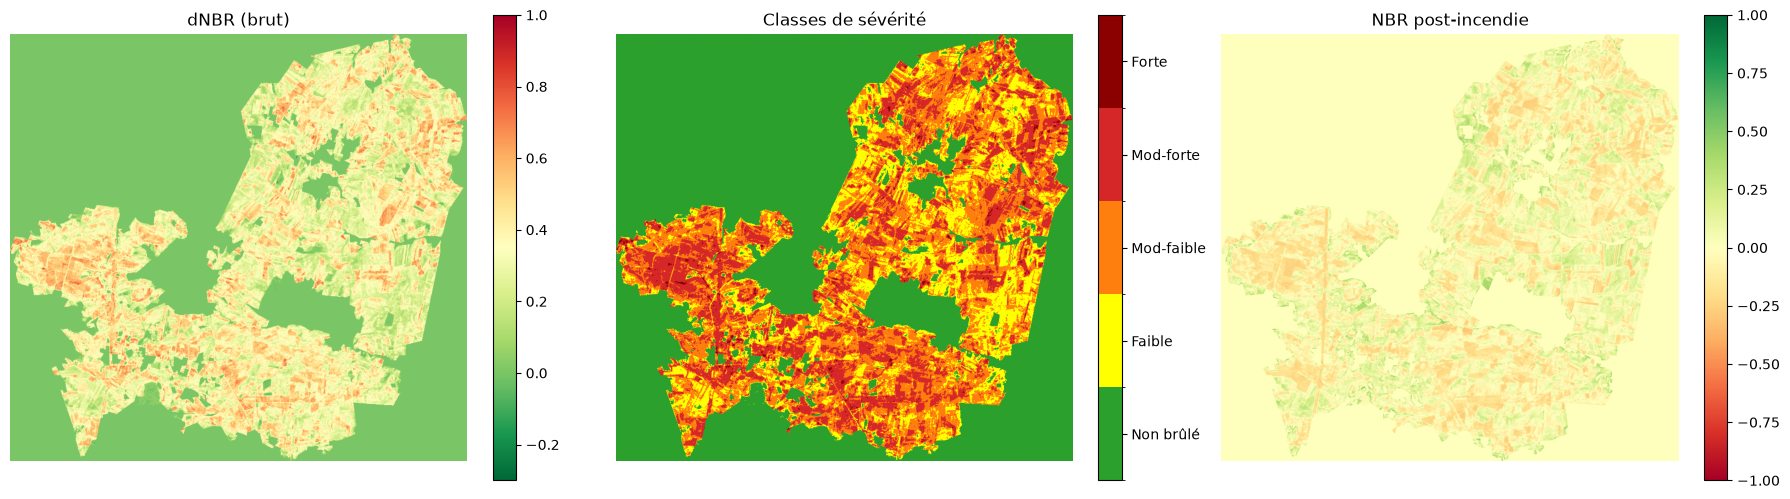

Surface brûlée par classe de sévérité :

  Non brûlé    :  13385.1 ha
  Faible       :   3199.2 ha
  Mod-faible   :   5478.4 ha
  Mod-forte    :   3473.1 ha
  Forte        :     98.6 ha

Total brûlé (classes 2-5) : 12249.3 ha


In [90]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

def classify_severity(dnbr):
    classes = np.zeros_like(dnbr, dtype="uint8")
    classes[(dnbr >= -0.1) & (dnbr < 0.1)] = 1
    classes[(dnbr >= 0.1) & (dnbr < 0.27)] = 2
    classes[(dnbr >= 0.27) & (dnbr < 0.44)] = 3
    classes[(dnbr >= 0.44) & (dnbr < 0.66)] = 4
    classes[dnbr >= 0.66] = 5
    return classes

severity = classify_severity(dnbr)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(dnbr, cmap="RdYlGn_r", vmin=-0.3, vmax=1.0)
axes[0].set_title("dNBR (brut)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

severity_colors = ["#2ca02c", "#ffff00", "#ff7f0e", "#d62728", "#8b0000"]
cmap = ListedColormap(severity_colors)
bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm = BoundaryNorm(bounds, cmap.N)
im1 = axes[1].imshow(severity, cmap=cmap, norm=norm)
axes[1].set_title("Classes de sévérité")
axes[1].axis("off")
cbar = plt.colorbar(im1, ax=axes[1], ticks=[1, 2, 3, 4, 5], fraction=0.046)
cbar.ax.set_yticklabels(["Non brûlé", "Faible", "Mod-faible", "Mod-forte", "Forte"])

im2 = axes[2].imshow(nbr_post, cmap="RdYlGn", vmin=-1, vmax=1)
axes[2].set_title("NBR post-incendie")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()


pixel_area_ha = (profile_pre["transform"][0] ** 2) / 10_000

print("Surface brûlée par classe de sévérité :\n")
for cls, label in zip([1,2,3,4,5], ["Non brûlé","Faible","Mod-faible","Mod-forte","Forte"]):
    n_pixels = (severity == cls).sum()
    print(f"  {label:12s} : {n_pixels * pixel_area_ha:8.1f} ha")

total_brule = ((severity >= 2)).sum() * pixel_area_ha
print(f"\nTotal brûlé (classes 2-5) : {total_brule:.1f} ha")